### CSP571 Assignment #2

This notebook contains the completed analysis for Assignment #2. The work is organized into two main parts:

- **Part 3:** Binary classification of facial-feature points, with a focus on identifying whether each point belongs to the nose.
- **Part 4:** Multi-class classification for the transportation-mode dataset using decision trees.


#### Part #3: Logistic Regression for Nose Classification

The goal of this section is to classify whether a facial coordinate belongs to the nose. The original dataset contains coordinate values and a `feature` label. I convert the original feature label into a binary target variable named `IS_NOSE`, where `1` means the observation is a nose point and `0` means it belongs to another facial feature.


**Library setup.** These imports cover data manipulation, visualization, model training, and model evaluation. The same imports are reused in both parts of the assignment.


In [1]:
# Import libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


In [2]:
# Import Scikit-Learn libraries for machine learning
from sklearn.model_selection import train_test_split

# Import Scikit-Learn libraries for logistic regression
from sklearn.linear_model import LogisticRegression

# Import Scikit-Learn libraries for classification matrix 
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


**Load and preview the face data.** The file `Face.csv` is expected to be in the same folder as this notebook. The first few rows are displayed to confirm that the coordinate and feature columns were read correctly.


In [3]:
# Load the dataset in csv format
df_part3 = pd.read_csv('Face.csv')

# Inspect the loaded dataframe
df_part3.head()


,horizontal,vertical,feature
0,-1.20,0.763,1
1,-1.20,0.763,1
2,-1.15,0.543,1
3,-1.15,0.983,1
4,-1.10,0.463,1


**Data-quality check.** Before modeling, I check for missing values so that any required cleaning step would be visible before the train/test split.


In [4]:
# Check whether any column contains missing values.
df_part3.isnull().sum()


horizontal    0
vertical      0
feature       0
dtype: int64

**Class distribution check.** The original `feature` labels are counted to understand how many examples belong to each facial feature.


In [5]:
# Count the original feature categories before creating the binary target.
df_part3['feature'].value_counts()


feature
1    38
2    38
3    31
4    22
Name: count, dtype: int64

**Create the binary target.** Since the modeling question is whether a point is part of the nose, the multi-class `feature` column is converted into the binary indicator `IS_NOSE`.


In [6]:
''' 
Feature 1 = Right Eye 
Feature 2 = Left Eye
Feature 3 = Nose
Feature 4 = Mouth
'''

# Create another indicator variable IS_NOSE
df_part3['IS_NOSE'] = (df_part3['feature'] == 3).astype(int)

# Show the new column
df_part3.head()


,horizontal,vertical,feature,IS_NOSE
0,-1.20,0.763,1,0
1,-1.20,0.763,1,0
2,-1.15,0.543,1,0
3,-1.15,0.983,1,0
4,-1.10,0.463,1,0


In [7]:
# Count the number of observations in each binary target class.
df_part3['IS_NOSE'].value_counts()


IS_NOSE
0    98
1    31
Name: count, dtype: int64

**Train/test split.** The coordinate columns are used as predictors, and `IS_NOSE` is used as the target. Stratification keeps the nose/non-nose proportion similar in both the training and testing sets.


In [8]:
# Split the original-coordinate data into training and testing sets.

# Features and target
X = df_part3[['horizontal', 'vertical']]
y = df_part3['IS_NOSE']

# Stratified train/test split: 80% training, 20% testing 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=60616,
    stratify=y
)


In [9]:
print("Original:")
print(y.value_counts())

print("\nTraining:")
print(y_train.value_counts())

print("\nTesting:")
print(y_test.value_counts())


Original:
IS_NOSE
0    98
1    31
Name: count, dtype: int64

Training:
IS_NOSE
0    78
1    25
Name: count, dtype: int64

Testing:
IS_NOSE
0    20
1     6
Name: count, dtype: int64


**Fit the first logistic-regression model.** This baseline model uses the original Cartesian coordinates, `horizontal` and `vertical`, as predictors.


In [10]:
# Create the logistic regression model for the original coordinate features.
model_logistic = LogisticRegression(
    random_state=60616,
    max_iter=1000
)

# Train the model using training data
model_logistic.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",60616
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

**Inspect model coefficients.** The intercept and coefficients show the fitted linear relationship between the coordinate predictors and the log-odds of being classified as a nose point.


In [11]:
# Display the fitted intercept and coefficients for interpretation.
print("Intercept:", model_logistic.intercept_)
print("Coefficient:", model_logistic.coef_)

coef_df = pd.DataFrame({
    'Feature': ['horizontal', 'vertical'],
    'Coefficient': model_logistic.coef_[0]
})

coef_df


Intercept: [-1.2069502]
Coefficient: [[-0.18631471 -0.75042227]]


,Feature,Coefficient
0,horizontal,-0.186315
1,vertical,-0.750422


**Evaluate classification accuracy.** The fitted model predicts labels for the held-out test set, and accuracy measures the proportion of correct predictions.


In [12]:
# Predict target labels on the held-out test set.
y_pred = model_logistic.predict(X_test)

# Compute test accuracy
test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy", np.round(test_accuracy, 4))


Test Accuracy 0.5385


**Confusion matrix.** The confusion matrix gives a more detailed view than accuracy by showing true negatives, false positives, false negatives, and true positives.


In [13]:
# Generate the confusion matrix for the baseline logistic model.
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[14  6]
 [ 6  0]]


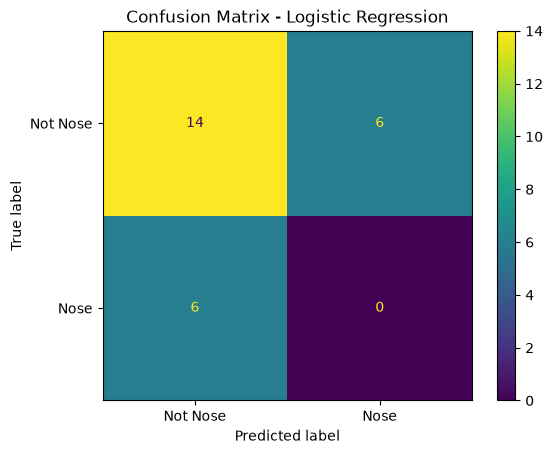

In [14]:
# Display the confusion matrix with readable class labels.
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Nose', 'Nose']
)

display.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


**Visualize predicted labels.** Plotting the test-set coordinates by predicted class helps show how the logistic-regression boundary behaves spatially.


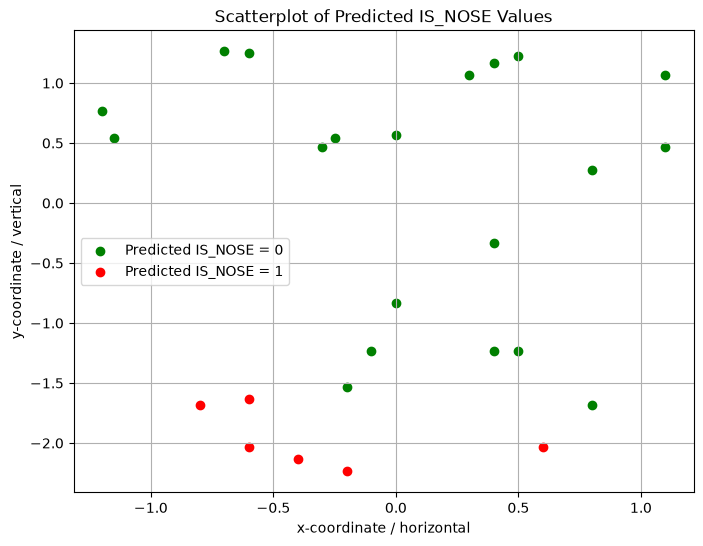

In [15]:
# Plot test-set points using their predicted binary labels.
plot_df = X_test.copy()
plot_df['Predicted_IS_NOSE'] = y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    plot_df.loc[plot_df['Predicted_IS_NOSE'] == 0, 'horizontal'],
    plot_df.loc[plot_df['Predicted_IS_NOSE'] == 0, 'vertical'],
    color='green',
    label='Predicted IS_NOSE = 0'
)

plt.scatter(
    plot_df.loc[plot_df['Predicted_IS_NOSE'] == 1, 'horizontal'],
    plot_df.loc[plot_df['Predicted_IS_NOSE'] == 1, 'vertical'],
    color='red',
    label='Predicted IS_NOSE = 1'
)


plt.xlabel('x-coordinate / horizontal')
plt.ylabel('y-coordinate / vertical')
plt.title('Scatterplot of Predicted IS_NOSE Values')
plt.legend()
plt.grid(True)
plt.show()


**Coordinate transformation.** The next model uses polar-style features. Shifting the horizontal coordinate by `0.2` before calculating `r` and `theta` changes the origin of the transformation and can make the nose pattern easier for a linear classifier to separate.


In [16]:
# Transform Cartesian coordinates into shifted polar-coordinate features.
df_part3['r'] = np.sqrt((df_part3['horizontal'] + 0.2)**2 + df_part3['vertical']**2)
df_part3['theta'] = np.arctan2(df_part3['vertical'], df_part3['horizontal'] + 0.2)


In [17]:
# Inspect the updated dataframe
df_part3.head()


,horizontal,vertical,feature,IS_NOSE,r,theta
0,-1.20,0.763,1,0,1.257843,2.489823
1,-1.20,0.763,1,0,1.257843,2.489823
2,-1.15,0.543,1,0,1.094234,2.622333
3,-1.15,0.983,1,0,1.367037,2.339124
4,-1.10,0.463,1,0,1.012111,2.666456


**Train/test split using transformed features.** The target remains `IS_NOSE`, but the predictors are now `r` and `theta` instead of the original coordinate columns.


In [18]:
# Use the transformed polar features with the same binary target.
X_polar = df_part3[['r', 'theta']]
y = df_part3['IS_NOSE']

# Stratified train/test split 
X_train_polar, X_test_polar, y_train_polar, y_test_polar = train_test_split(
    X_polar,
    y,
    train_size=0.8,
    random_state=60616,
    stratify=y
)


**Fit logistic regression with transformed features.** This checks whether the polar-coordinate representation improves classification performance.


In [19]:
# Train logistic regression using the transformed polar-coordinate predictors.
model_logistic_polar = LogisticRegression(
    random_state=60616,
    max_iter=1000
)

model_logistic_polar.fit(X_train_polar, y_train_polar)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",60616
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

**Inspect the transformed-model coefficients.** The intercept and coefficients show how the fitted polar-coordinate predictors relate to the log-odds of being classified as nose.



In [20]:
# Check Model Intercept and Coefficients

print("Intercept:", model_logistic_polar.intercept_)

print("Coefficient:", model_logistic_polar.coef_)


coef_df = pd.DataFrame({

    'Feature': ['r', 'theta'],

    'Coefficient': model_logistic_polar.coef_[0]

})


coef_df

Intercept: [2.40563841]
Coefficient: [[-3.29029435 -1.57685694]]


,Feature,Coefficient
0,r,-3.290294
1,theta,-1.576857


**Evaluate the transformed-feature model.** Accuracy and the confusion matrix are recomputed so the transformed model can be compared with the original-coordinate model.


In [21]:
# Predict test labels using the polar-coordinate model.
y_pred_polar = model_logistic_polar.predict(X_test_polar)

# Check classification accuracy for the polar-coordinate model.
accuracy_polar = accuracy_score(y_test_polar, y_pred_polar)
print("The classification accuracy using the model trained dataset in polar coordinates is:", np.round(accuracy_polar, 4))

# New confusion matrix
cm_polar = confusion_matrix(y_test_polar, y_pred_polar)
print("Confusion Matrix:")
print(cm_polar)


The classification accuracy using the model trained dataset in polar coordinates is: 0.8846
Confusion Matrix:
[[20  0]
 [ 3  3]]


**Display the transformed-model confusion matrix.** The labeled matrix makes the polar-coordinate model errors easier to read than the raw array alone.



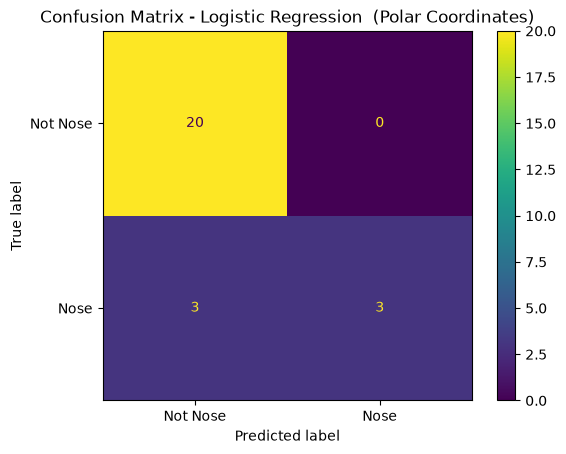

In [22]:
# Display confusion matrix

display = ConfusionMatrixDisplay(

    confusion_matrix=cm_polar,

    display_labels=['Not Nose', 'Nose']

)


display.plot()

plt.title("Confusion Matrix - Logistic Regression  (Polar Coordinates)")

plt.show()

**Visualize polar-model predictions in the original coordinate space.** Even though the model is trained on `r` and `theta`, plotting predictions by `horizontal` and `vertical` makes the spatial classification pattern easy to compare with the earlier scatter plot.



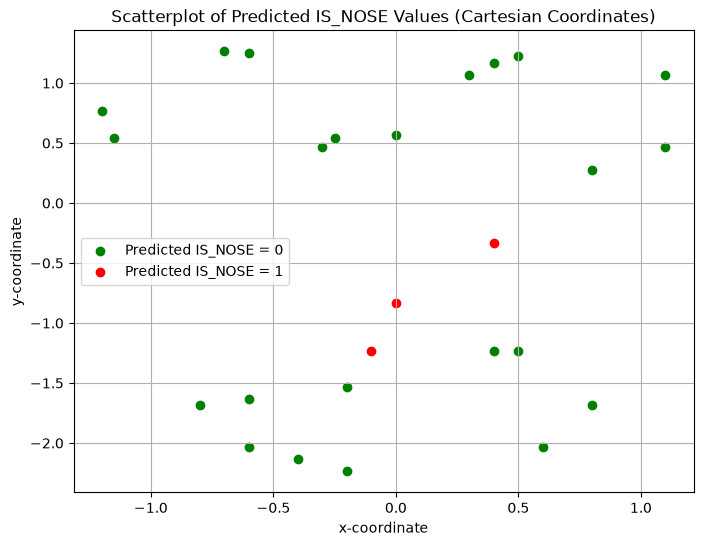

In [23]:
# Make the scatter plot based on the predicted labels, predicted by predictors in polar coordinates

plot_df_polar = df_part3.loc[X_test_polar.index, ['horizontal', 'vertical']].copy()

plot_df_polar['Predicted_IS_NOSE_Polar'] = y_pred_polar


plt.figure(figsize=(8,6))


plt.scatter(

    plot_df_polar.loc[plot_df_polar['Predicted_IS_NOSE_Polar'] == 0, 'horizontal'],

    plot_df_polar.loc[plot_df_polar['Predicted_IS_NOSE_Polar'] == 0, 'vertical'],

    color='green',

    label='Predicted IS_NOSE = 0'

)


plt.scatter(

    plot_df_polar.loc[plot_df_polar['Predicted_IS_NOSE_Polar'] == 1, 'horizontal'],

    plot_df_polar.loc[plot_df_polar['Predicted_IS_NOSE_Polar'] == 1, 'vertical'],

    color='red',

    label='Predicted IS_NOSE = 1'

)



plt.xlabel('x-coordinate')

plt.ylabel('y-coordinate')

plt.title('Scatterplot of Predicted IS_NOSE Values (Cartesian Coordinates)')

plt.legend()

plt.grid(True)

plt.show()

### Part #4: Decision Tree Classification

This section uses `sample_v10.csv` to build a multi-class decision-tree classifier. The target variable is `y`, which contains transportation-mode labels. The predictor variables are the ten numeric columns `x1` through `x10`.


**Load and preview the Part 4 data.** The dataset is read from `sample_v10.csv`, and the first rows are displayed to verify the column layout.


In [24]:
# Load the multi-class transportation-mode dataset for Part 4.
df_part4 = pd.read_csv('sample_v10.csv')

# Inspect the loaded dataframe
df_part4.head()


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,10.0071,-3.8675,6.6899,33.1367,24.3674,-1.7803,-1.2021,-49.9108,-35.0150,-69.6709,Bicycle
1,4.0799,5.3650,22.6921,5.8840,-7.3794,9.4086,-47.1878,-26.5750,90.0186,51.9291,Walk
2,4.4219,-5.1384,19.9140,30.2850,18.3257,-7.5855,-4.9785,-43.7822,27.4785,-24.0543,Bicycle
3,2.4046,1.0938,-22.8637,47.5924,4.2035,29.6571,22.1897,-9.1959,75.0079,4.3526,Taxi
4,-3.1989,10.1843,-9.7620,-7.9439,2.7512,5.4564,-20.1493,-3.7285,9.7938,16.1566,Bus


**Missing-value check.** This verifies whether any predictor or target column needs cleaning before the decision-tree model is trained.


In [25]:
# Check whether any predictor or target column contains missing values.
df_part4.isnull().sum()


x1     0
x2     0
x3     0
x4     0
x5     0
x6     0
x7     0
x8     0
x9     0
x10    0
y      0
dtype: int64

**Separate predictors and target.** The response column `y` is removed from the predictor matrix and stored separately as the classification target.


In [26]:
# Separate the Part 4 data into predictors and target.

# Features and target
X = df_part4.drop(['y'], axis=1)
y = df_part4['y']


**Stratified train/test split.** A 70/30 split is used, and stratification preserves the class proportions across the original, training, and testing data.


In [27]:
# Stratified train/test split: 70% training, 30% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=20231225,
    stratify=y
)


**Verify class balance after splitting.** The normalized class counts confirm that the stratified split kept similar label proportions in the training and testing sets.


In [28]:
print("Original:")
print(y.value_counts(normalize=True).round(2))

print("\nTraining:")
print(y_train.value_counts(normalize=True).round(2))

print("\nTesting:")
print(y_test.value_counts(normalize=True).round(2))


Original:
y
Bicycle    0.27
Walk       0.23
Taxi       0.23
Bus        0.14
Others     0.13
Name: proportion, dtype: float64

Training:
y
Bicycle    0.27
Walk       0.23
Taxi       0.23
Bus        0.14
Others     0.13
Name: proportion, dtype: float64

Testing:
y
Bicycle    0.27
Walk       0.23
Taxi       0.23
Bus        0.14
Others     0.13
Name: proportion, dtype: float64


**Tune tree depth.** Decision trees can overfit when they are too deep. This loop trains trees with depths from 1 to 20 and records both training and testing accuracy.


In [29]:
# Train decision trees with depths from 1 to 20 and compare performance.
depth_of_tree = []
test_accuracy = []
train_accuracy = []
for depth in range(1, 21):
    classifier_bikeshare = DecisionTreeClassifier(random_state=20231225, max_depth=depth, criterion='entropy')
    classifier_bikeshare.fit(X_train, y_train)

    predicted_bikeshare_train = classifier_bikeshare.predict(X_train)
    accuracy_train = accuracy_score(y_train, predicted_bikeshare_train)

    predicted_bikeshare = classifier_bikeshare.predict(X_test)
    accuracy = accuracy_score(y_test, predicted_bikeshare)


    depth_of_tree.append(depth)
    test_accuracy.append(accuracy)
    train_accuracy.append(accuracy_train)


In [30]:
print(depth_of_tree)


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


**Compare training and testing accuracy.** The plot helps choose a tree depth that performs well on the test set without unnecessarily increasing model complexity.


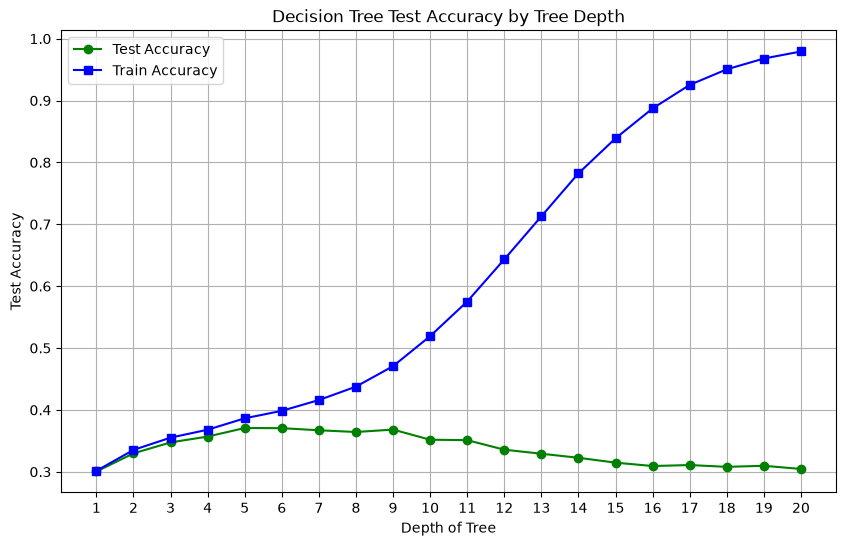

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(depth_of_tree, test_accuracy, marker = 'o', color = 'green', label = 'Test Accuracy')
plt.plot(depth_of_tree, train_accuracy, marker = 's', color = 'blue', label = 'Train Accuracy')
plt.xlabel('Depth of Tree')
plt.ylabel('Test Accuracy')
plt.title('Decision Tree Test Accuracy by Tree Depth')
plt.xticks(range(1, 21))
plt.legend()
plt.grid(True)
plt.show()


**Train the final decision tree.** Based on the depth comparison, `max_depth=5` is selected for the final classifier.


In [32]:
best_depth = 5

classifier_bikeshare = DecisionTreeClassifier(
    random_state=20231225,
    max_depth=best_depth,
    criterion='entropy'
)

classifier_bikeshare.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",20231225
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsa

**Generate predicted class probabilities.** The probability matrix contains one probability per class for each test observation. These probabilities are used for the histograms in the next step.


In [33]:
y_prob = classifier_bikeshare.predict_proba(X_test)
y_prob


array([[0.3256433 , 0.03992902, 0.13398403, 0.30700976, 0.1934339 ],
       [0.29491525, 0.09491525, 0.06440678, 0.18305085, 0.36271186],
       [0.37752161, 0.09798271, 0.0518732 , 0.21325648, 0.25936599],
       ...,
       [0.14487179, 0.42307692, 0.00384615, 0.03205128, 0.39615385],
       [0.3256433 , 0.03992902, 0.13398403, 0.30700976, 0.1934339 ],
       [0.34832757, 0.11188005, 0.06113033, 0.20069204, 0.27797001]],
      shape=(8254, 5))

**Visualize probability distributions by actual class.** The grid of histograms shows how strongly the model assigns each predicted-class probability for observations from each true class.


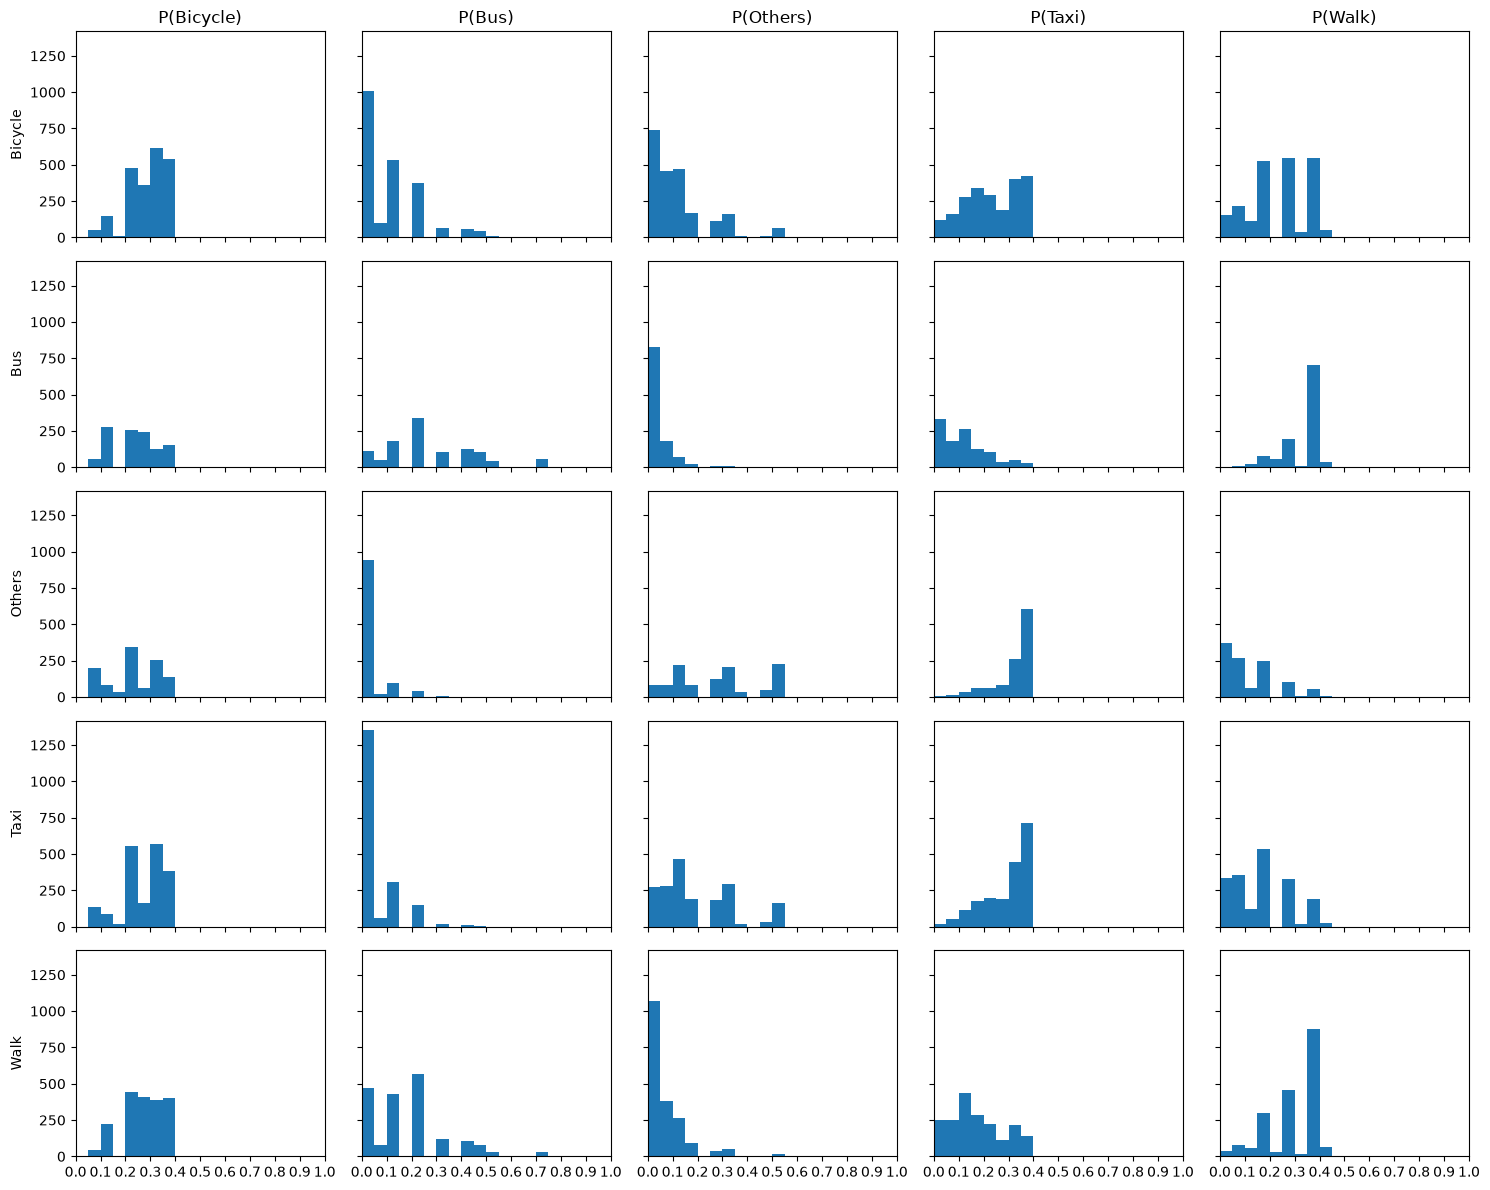

In [34]:
classes = classifier_bikeshare.classes_

fig, axes = plt.subplots(
    nrows=5,
    ncols=5,
    figsize=(15, 12),
    sharex=True,
    sharey=True
)

# histogram bin width = 0.05
bins = np.arange(0, 1.05, 0.05)


for row, actual_class in enumerate(classes):

    # select samples belonging to this actual class
    class_mask = (y_test == actual_class)

    for col, predicted_class in enumerate(classes):

        # probability column for this class
        class_index = list(classes).index(predicted_class)

        probabilities = y_prob[class_mask, class_index]

        axes[row, col].hist(
            probabilities,
            bins=bins
        )

        axes[row, col].set_xlim(0, 1)
        axes[row, col].set_xticks(np.arange(0, 1.1, 0.1))


        if row == 0:
            axes[row, col].set_title(
                f"P({predicted_class})"
            )

        if col == 0:
            axes[row, col].set_ylabel(
                actual_class
            )


plt.tight_layout()
plt.show()
